In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from sklearn.feature_selection import RFE, SelectKBest, f_regression

import warnings
warnings.filterwarnings('ignore')
import os
import random

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [10]:
df = pd.read_csv('/content/Bangladesh_Pneumonia_U5_Winter_10yrs.csv')
display(df.head())

,Month,District,Gender,Age_Months,Pneumonia_Admissions_U5,Min_Temp_C,Max_Temp_C,Humidity_Percent,Rainfall_mm,Avg_Wind_Speed_kmph,Air_Quality_Index,Hospital_Beds_Occupied,Vaccination_Coverage_Percent,Winter_Season_Flag
0,Jan,Mymensingh,Male,4,358,15.119210,29.123109,69.597488,33.319326,16.887262,84.054817,186,93.510587,1
1,Feb,Dhaka,Female,42,375,18.183409,26.331466,64.053100,115.318420,11.584214,110.451595,214,80.723512,1
2,Mar,Chittagong,Male,47,343,26.048940,25.949401,91.522160,NaN,7.805194,82.957110,237,82.060946,0
3,Apr,Khulna,Male,33,371,11.130868,28.996020,74.294530,66.246838,18.140084,124.061991,194,74.449366,0
4,May,Barishal,Male,39,383,22.275792,29.288699,69.591274,101.916925,7.995220,132.289314,208,82.858804,0


## Data Quality Checks

### Duplicates

In [11]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows. Removing them...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [12]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['Month', 'District', 'Gender']
Numerical columns: ['Age_Months', 'Pneumonia_Admissions_U5', 'Min_Temp_C', 'Max_Temp_C', 'Humidity_Percent', 'Rainfall_mm', 'Avg_Wind_Speed_kmph', 'Air_Quality_Index', 'Hospital_Beds_Occupied', 'Vaccination_Coverage_Percent', 'Winter_Season_Flag']


### Missing Values

In [13]:
# Impute remaining missing values in 'Rainfall_mm' and 'Humidity_Percent' with the mean

if 'Rainfall_mm' in df.columns:
    df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean(), inplace=True)
    print("Missing values in 'Rainfall_mm' imputed with the mean.")

if 'Humidity_Percent' in df.columns:
    df['Humidity_Percent'].fillna(df['Humidity_Percent'].mean(), inplace=True)
    print("Missing values in 'Humidity_Percent' imputed with the mean.")

# Recheck for missing values after all imputations:
print("\nMissing values after all imputations:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values in 'Rainfall_mm' imputed with the mean.
Missing values in 'Humidity_Percent' imputed with the mean.

Missing values after all imputations:


,0


### Outlier Detection and Handling

In [14]:
# Function to detect and cap outliers using IQR
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Identify numerical columns for outlier detection, excluding binary/categorical-like numeric columns
numerical_cols_for_outliers = [col for col in numerical_cols if col not in ['Winter_Season_Flag']]

print("Capping outliers using IQR method:")
for col in numerical_cols_for_outliers:
    cap_outliers_iqr(df, col)
    print(f"  Outliers in '{col}' have been capped.")

print("\nOutlier handling complete.")

Capping outliers using IQR method:
  Outliers in 'Age_Months' have been capped.
  Outliers in 'Pneumonia_Admissions_U5' have been capped.
  Outliers in 'Min_Temp_C' have been capped.
  Outliers in 'Max_Temp_C' have been capped.
  Outliers in 'Humidity_Percent' have been capped.
  Outliers in 'Rainfall_mm' have been capped.
  Outliers in 'Avg_Wind_Speed_kmph' have been capped.
  Outliers in 'Air_Quality_Index' have been capped.
  Outliers in 'Hospital_Beds_Occupied' have been capped.
  Outliers in 'Vaccination_Coverage_Percent' have been capped.

Outlier handling complete.


### Encoding Categorical Variables

In [15]:
# Apply One-Hot Encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df_encoded.head())

,Age_Months,Pneumonia_Admissions_U5,Min_Temp_C,Max_Temp_C,Humidity_Percent,Rainfall_mm,Avg_Wind_Speed_kmph,Air_Quality_Index,Hospital_Beds_Occupied,Vaccination_Coverage_Percent,Winter_Season_Flag,Month_Aug,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,District_Chittagong,District_Dhaka,District_Khulna,District_Mymensingh,District_Rajshahi,District_Rangpur,District_Sylhet,District_UnknownDistrict,Gender_Male
0,4.0,358.0,15.119210,29.123109,69.597488,33.319326,16.887262,84.054817,186.0,93.510587,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
1,42.0,375.0,18.183409,26.331466,64.053100,115.318420,11.584214,110.451595,214.0,80.723512,1,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,47.0,343.0,26.048940,25.949401,91.522160,80.636224,7.805194,82.957110,237.0,82.060946,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True
3,33.0,371.0,11.130868,28.996020,74.294530,66.246838,18.140084,124.061991,194.0,74.449366,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,39.0,383.0,22.275792,29.288699,69.591274,101.916925,7.995220,132.289314,208.0,82.858804,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


### Scaling Numerical Features

In [16]:
# Initialize StandardScaler
scaler = StandardScaler()

# Get the list of numerical columns from the original df after encoding.
# Exclude any newly created dummy variables from the scaling process.
numerical_cols_for_scaling = [col for col in numerical_cols if col in df_encoded.columns]

# Apply scaling to the numerical columns in df_encoded
df_encoded[numerical_cols_for_scaling] = scaler.fit_transform(df_encoded[numerical_cols_for_scaling])

print("Numerical features scaled using StandardScaler.")
display(df_encoded.head())

Numerical features scaled using StandardScaler.


,Age_Months,Pneumonia_Admissions_U5,Min_Temp_C,Max_Temp_C,Humidity_Percent,Rainfall_mm,Avg_Wind_Speed_kmph,Air_Quality_Index,Hospital_Beds_Occupied,Vaccination_Coverage_Percent,Winter_Season_Flag,Month_Aug,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,District_Chittagong,District_Dhaka,District_Khulna,District_Mymensingh,District_Rajshahi,District_Rangpur,District_Sylhet,District_UnknownDistrict,Gender_Male
0,-1.490051,-1.096441,-0.766708,0.280228,-0.422323,-1.543426,1.006760,-0.526445,-0.735701,1.584748,1.732051,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
1,0.657783,-0.643254,0.007717,-0.410042,-0.980406,1.130400,-0.099337,0.831884,0.693715,-0.778503,1.732051,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,0.940393,-1.496312,1.995599,-0.504512,1.784552,-0.000517,-0.887555,-0.582931,1.867878,-0.531325,-0.577350,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True
3,0.149086,-0.749886,-1.774695,0.248804,0.050468,-0.469726,1.268071,1.532249,-0.327296,-1.938063,-0.577350,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,0.488217,-0.429989,1.041999,0.321172,-0.422949,0.693404,-0.847920,1.955612,0.387412,-0.383868,-0.577350,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


## Exploratory Data Analysis (EDA)

### Distribution of Pneumonia Admissions (U5)

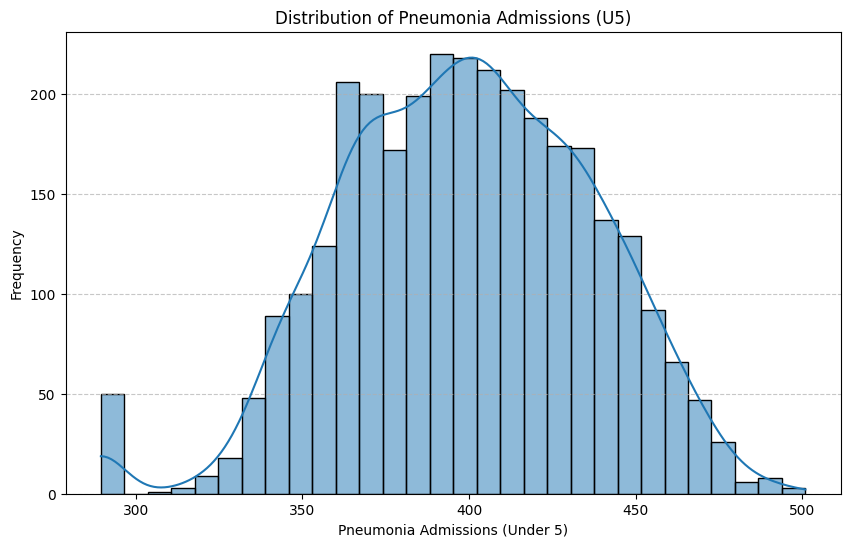


Descriptive Statistics for Pneumonia_Admissions_U5:


,Pneumonia_Admissions_U5
count,3120.000000
mean,399.129808
std,37.518122
min,289.500000
25%,372.000000
50%,400.000000
75%,427.000000
max,501.000000


In [17]:
target_variable = 'Pneumonia_Admissions_U5'

plt.figure(figsize=(10, 6))
sns.histplot(df[target_variable], kde=True, bins=30)
plt.title('Distribution of Pneumonia Admissions (U5)')
plt.xlabel('Pneumonia Admissions (Under 5)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nDescriptive Statistics for Pneumonia_Admissions_U5:")
display(df[target_variable].describe())

### Correlation Matrix

In [18]:
# Calculate correlations with the target variable in the encoded DataFrame
correlations = df_encoded.corr()[target_variable].sort_values(ascending=False)

print("Correlation of features with '{}':".format(target_variable))
display(correlations.drop(target_variable))

Correlation of features with 'Pneumonia_Admissions_U5':


,Pneumonia_Admissions_U5
Month_Feb,0.104622
Month_Nov,0.079179
Humidity_Percent,0.065830
Month_Sep,0.058838
Max_Temp_C,0.056823
...,...
Month_Jun,-0.049733
Month_Mar,-0.072734
Rainfall_mm,-0.074351
Month_Dec,-0.107960


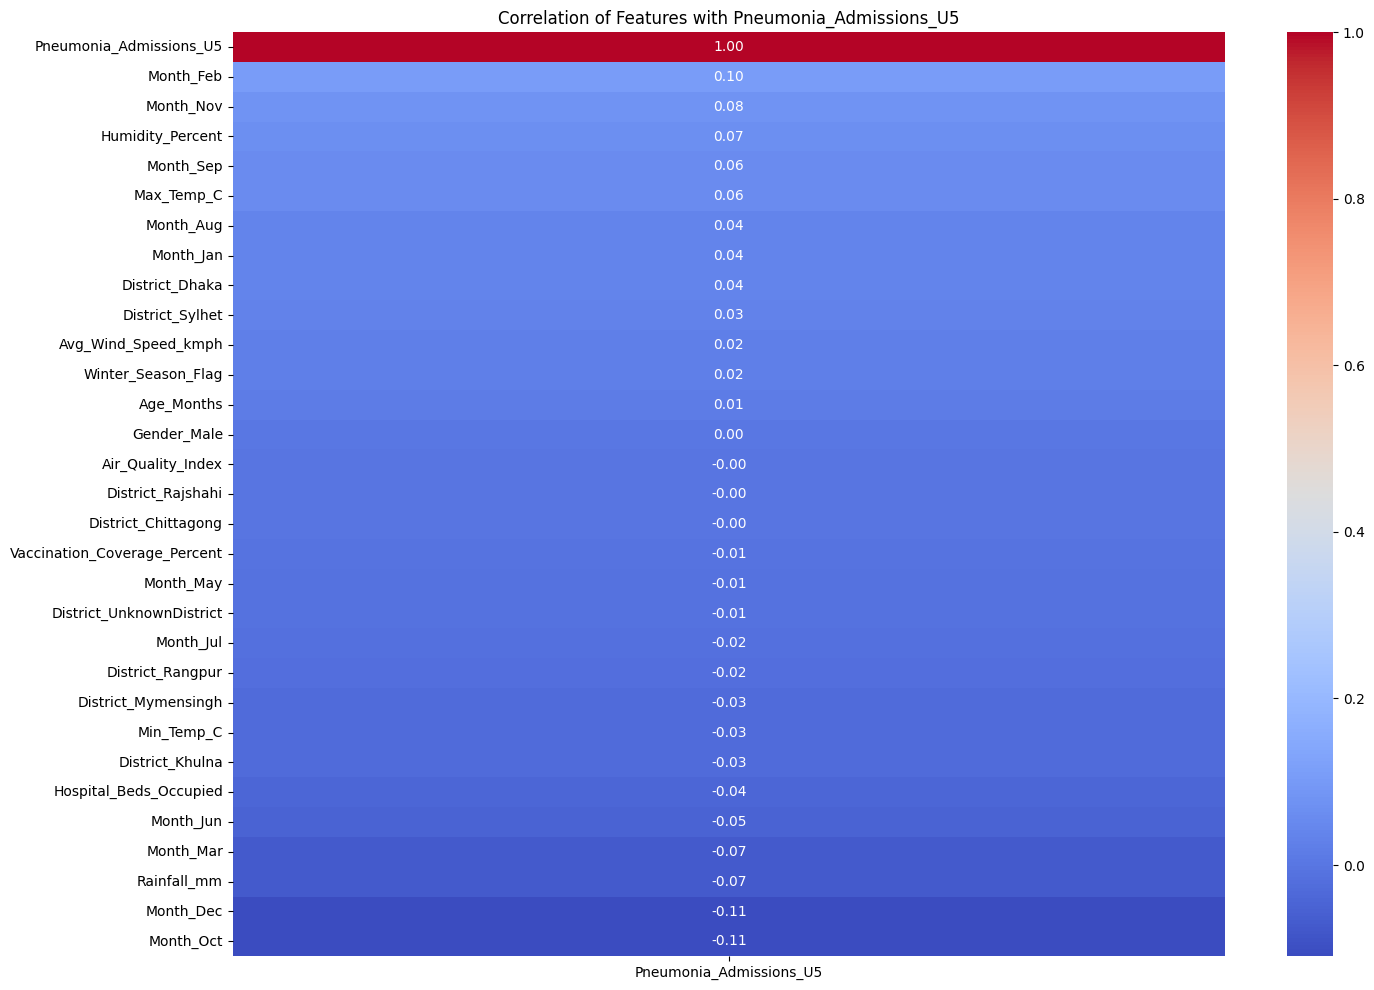

In [19]:
plt.figure(figsize=(16, 12))
sns.heatmap(df_encoded.corr()[[target_variable]].sort_values(by=target_variable, ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Correlation of Features with {target_variable}')
plt.show()

### Relationship between Pneumonia Admissions and Temperature

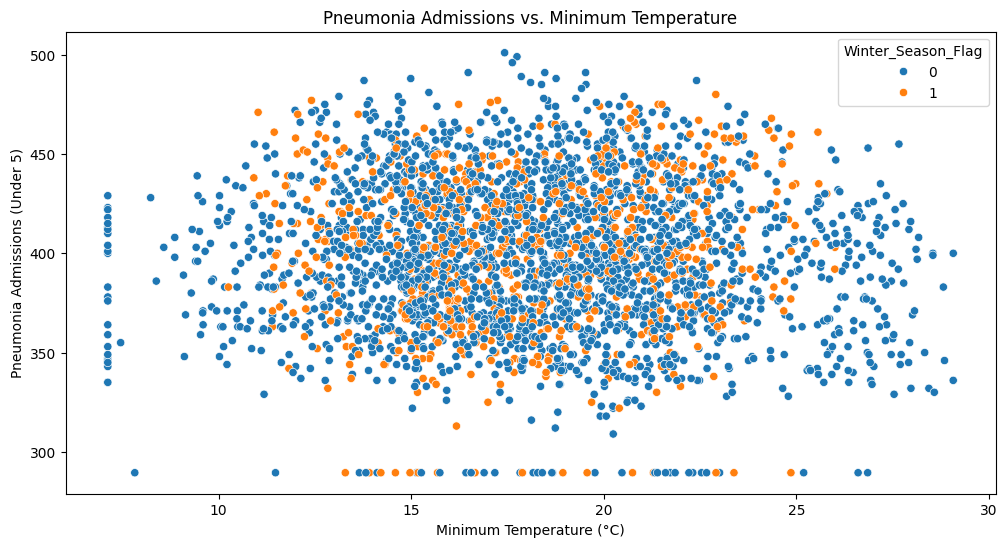

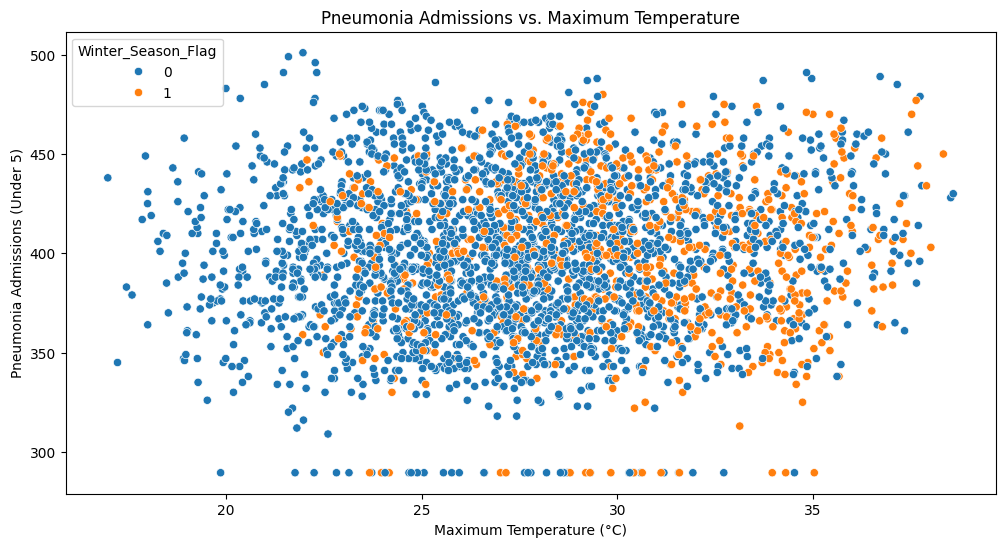

In [20]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Min_Temp_C', y='Pneumonia_Admissions_U5', hue='Winter_Season_Flag')
plt.title('Pneumonia Admissions vs. Minimum Temperature')
plt.xlabel('Minimum Temperature (°C)')
plt.ylabel('Pneumonia Admissions (Under 5)')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Max_Temp_C', y='Pneumonia_Admissions_U5', hue='Winter_Season_Flag')
plt.title('Pneumonia Admissions vs. Maximum Temperature')
plt.xlabel('Maximum Temperature (°C)')
plt.ylabel('Pneumonia Admissions (Under 5)')
plt.show()

### Pneumonia Admissions by District and Gender

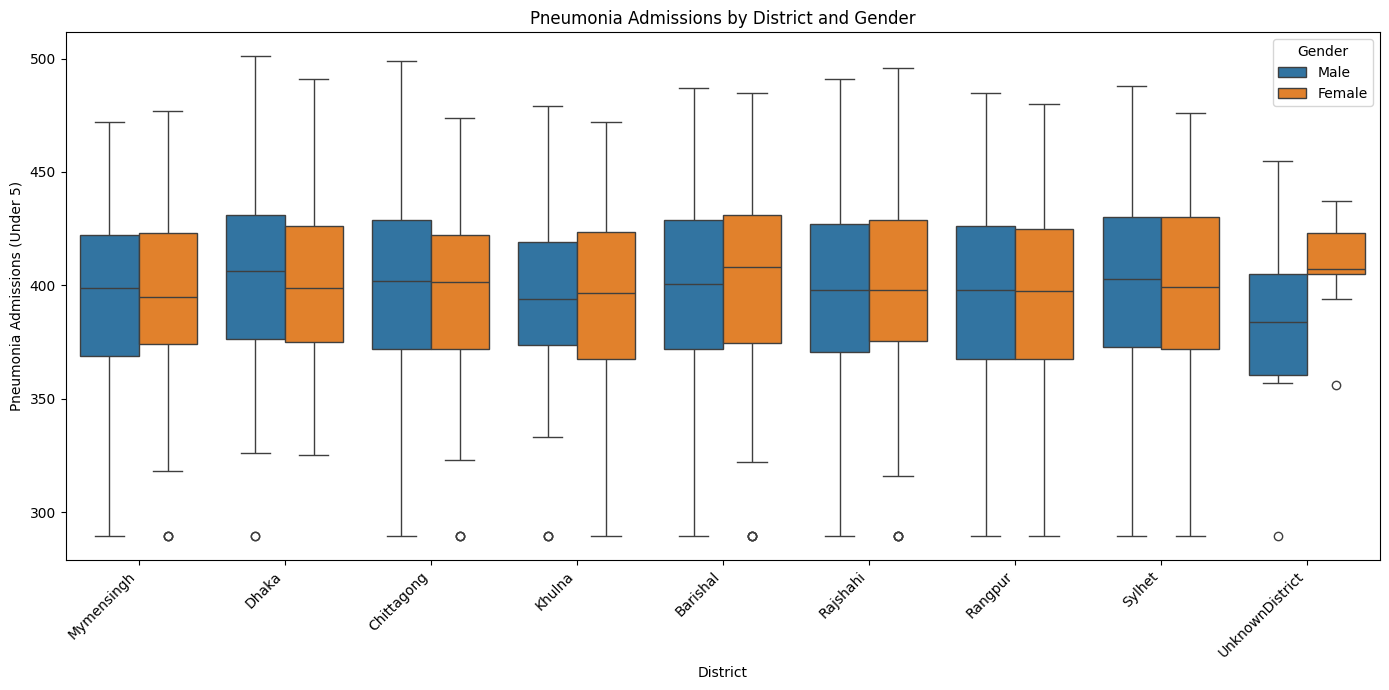

In [21]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='District', y='Pneumonia_Admissions_U5', hue='Gender')
plt.title('Pneumonia Admissions by District and Gender')
plt.xlabel('District')
plt.ylabel('Pneumonia Admissions (Under 5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Pneumonia Admissions vs. Vaccination Coverage

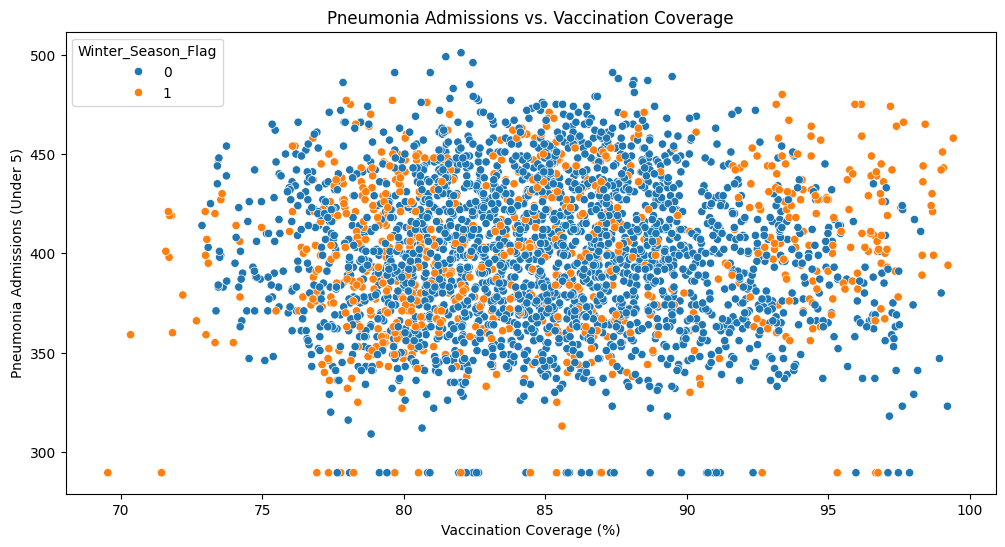

In [22]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Vaccination_Coverage_Percent', y='Pneumonia_Admissions_U5', hue='Winter_Season_Flag')
plt.title('Pneumonia Admissions vs. Vaccination Coverage')
plt.xlabel('Vaccination Coverage (%)')
plt.ylabel('Pneumonia Admissions (Under 5)')
plt.show()

### Distribution of Age

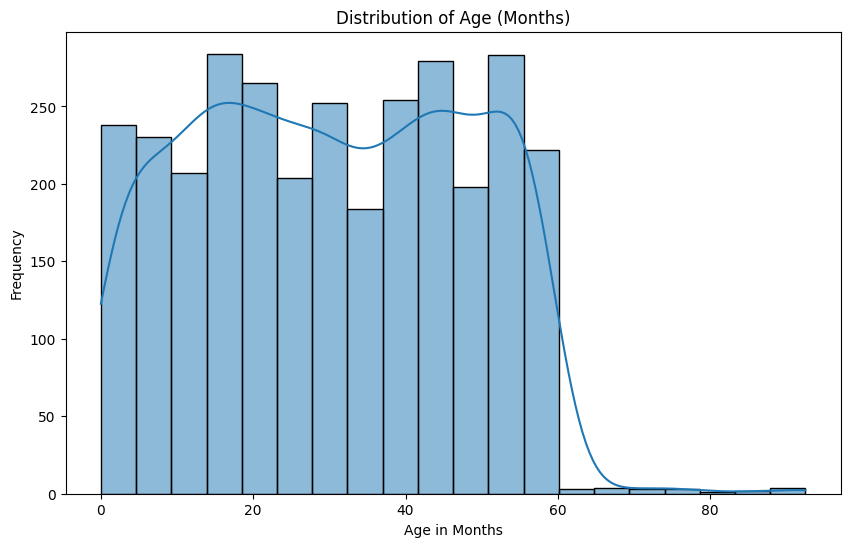

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age_Months'], kde=True, bins=20)
plt.title('Distribution of Age (Months)')
plt.xlabel('Age in Months')
plt.ylabel('Frequency')
plt.show()

### Boxplots for Environmental Factors (AQI, Temperature, Humidity)

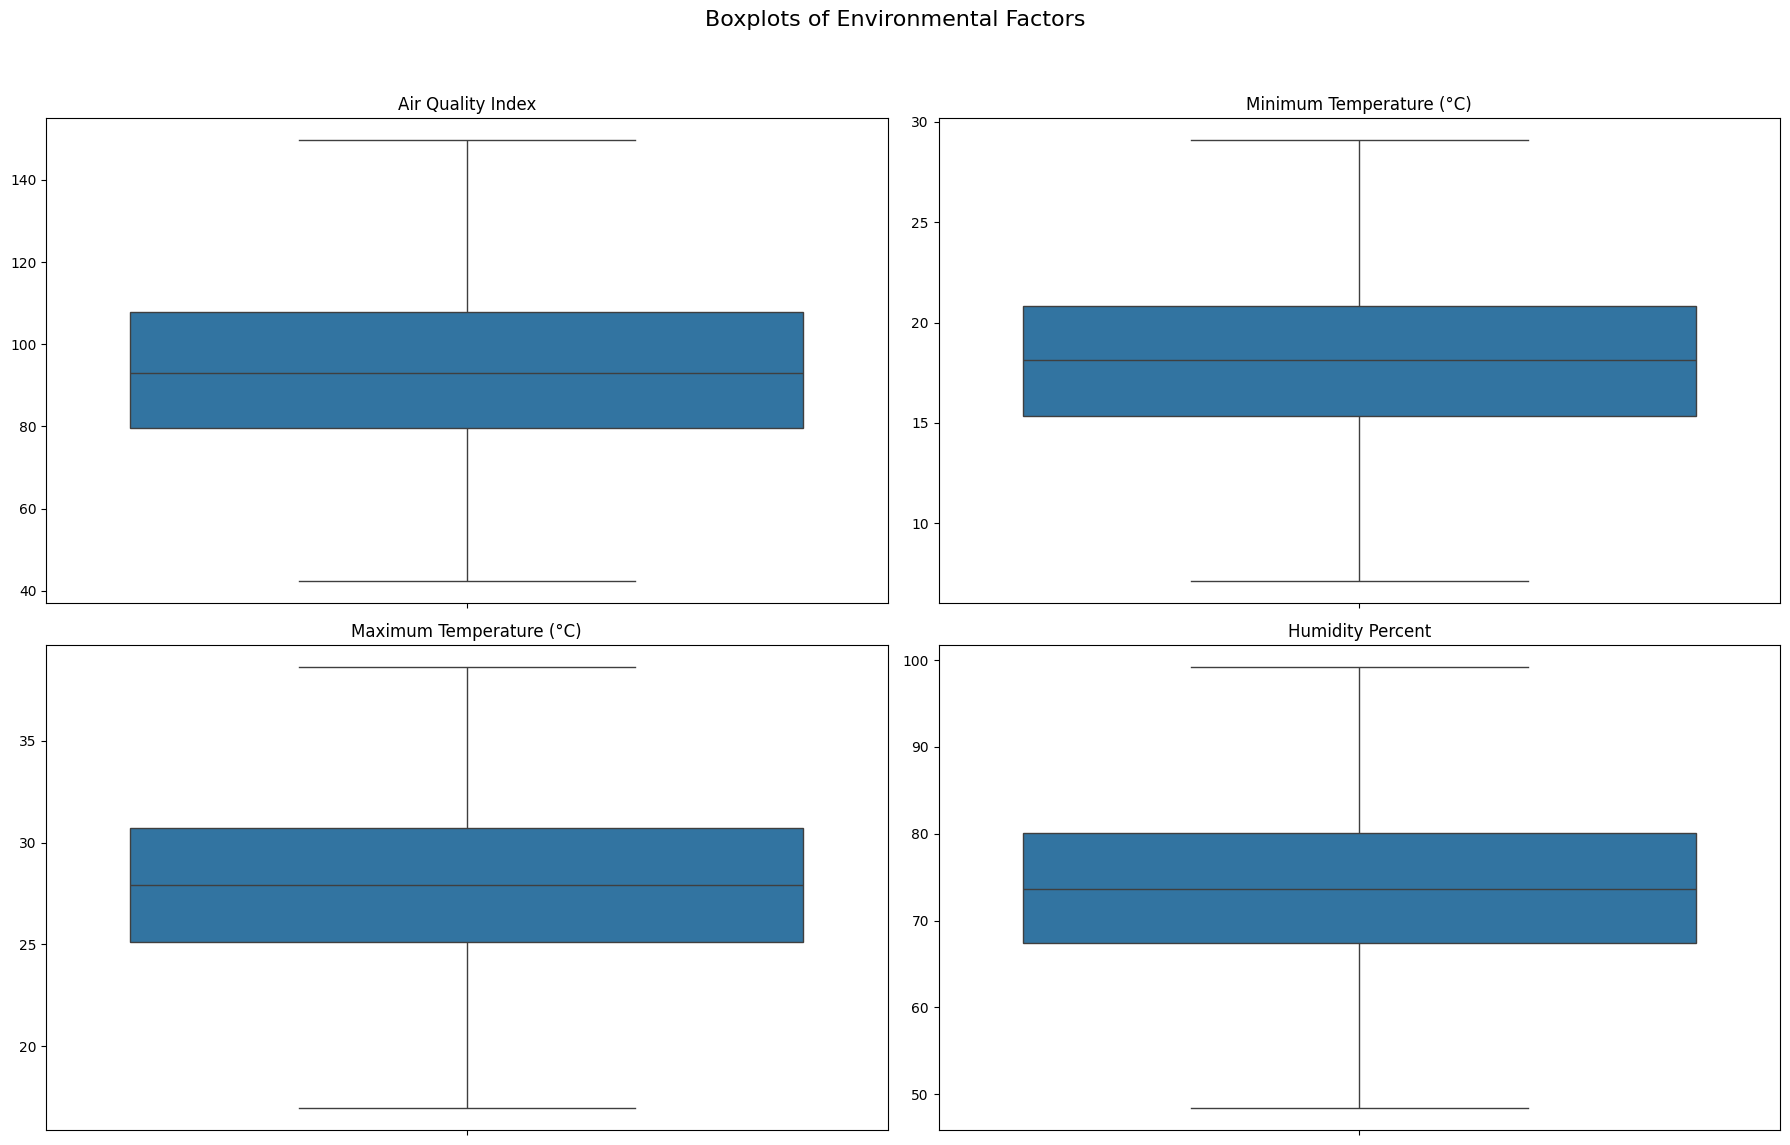

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Boxplots of Environmental Factors', fontsize=16)

sns.boxplot(ax=axes[0, 0], y=df['Air_Quality_Index'])
axes[0, 0].set_title('Air Quality Index')
axes[0, 0].set_ylabel('')

sns.boxplot(ax=axes[0, 1], y=df['Min_Temp_C'])
axes[0, 1].set_title('Minimum Temperature (°C)')
axes[0, 1].set_ylabel('')

sns.boxplot(ax=axes[1, 0], y=df['Max_Temp_C'])
axes[1, 0].set_title('Maximum Temperature (°C)')
axes[1, 0].set_ylabel('')

sns.boxplot(ax=axes[1, 1], y=df['Humidity_Percent'])
axes[1, 1].set_title('Humidity Percent')
axes[1, 1].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Monthly Trends

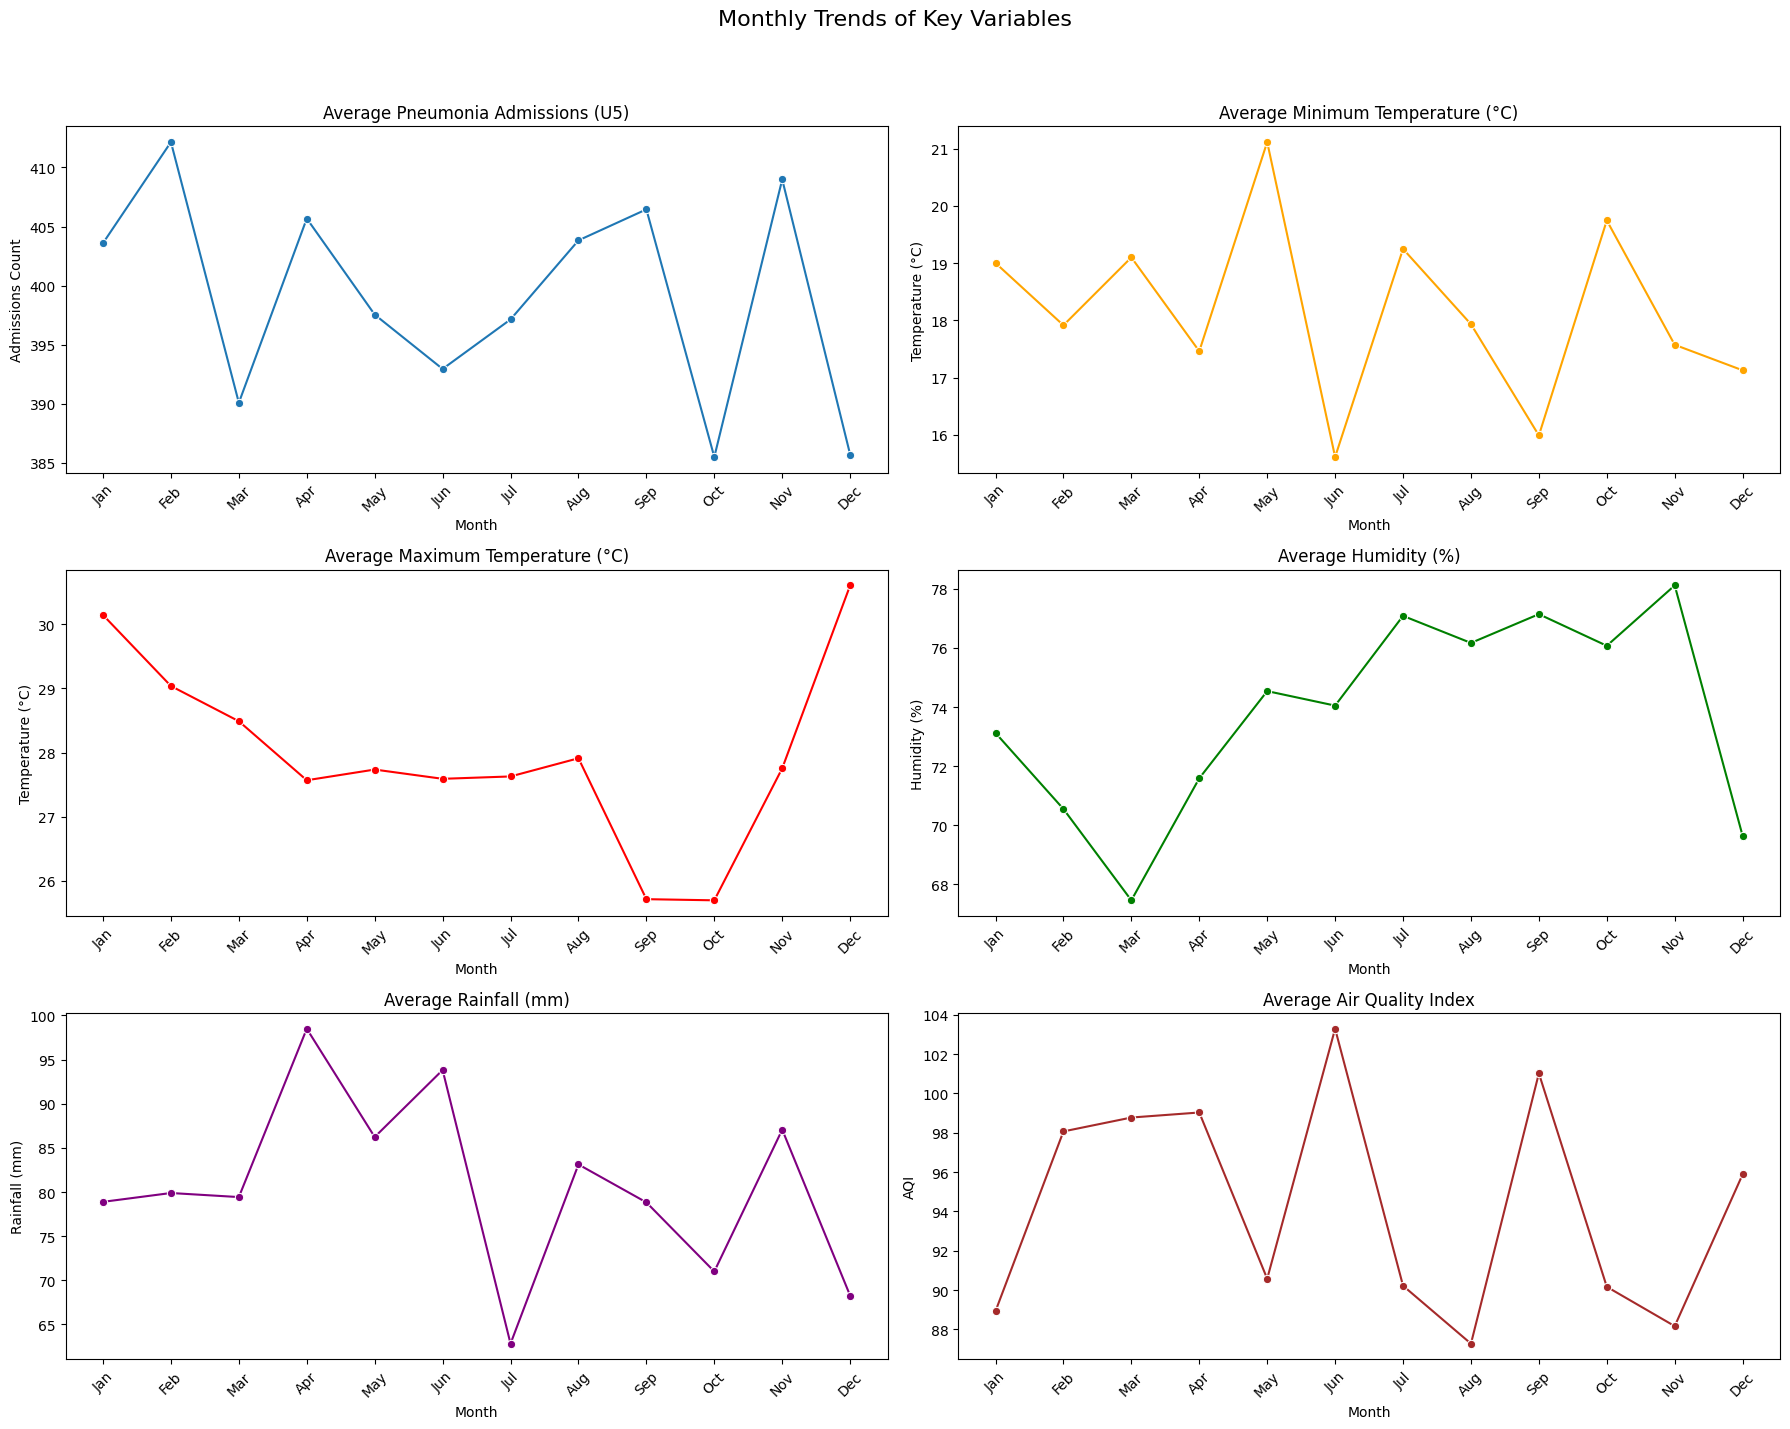

In [25]:
# Define the order of months for plotting
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Group by month and calculate the mean of relevant numerical columns
monthly_avg = df.groupby('Month')[['Pneumonia_Admissions_U5', 'Min_Temp_C', 'Max_Temp_C', 'Humidity_Percent', 'Rainfall_mm', 'Air_Quality_Index']].mean().reset_index()

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Monthly Trends of Key Variables', fontsize=16)

sns.lineplot(ax=axes[0, 0], x='Month', y='Pneumonia_Admissions_U5', data=monthly_avg, marker='o')
axes[0, 0].set_title('Average Pneumonia Admissions (U5)')
axes[0, 0].set_ylabel('Admissions Count')

sns.lineplot(ax=axes[0, 1], x='Month', y='Min_Temp_C', data=monthly_avg, marker='o', color='orange')
axes[0, 1].set_title('Average Minimum Temperature (°C)')
axes[0, 1].set_ylabel('Temperature (°C)')

sns.lineplot(ax=axes[1, 0], x='Month', y='Max_Temp_C', data=monthly_avg, marker='o', color='red')
axes[1, 0].set_title('Average Maximum Temperature (°C)')
axes[1, 0].set_ylabel('Temperature (°C)')

sns.lineplot(ax=axes[1, 1], x='Month', y='Humidity_Percent', data=monthly_avg, marker='o', color='green')
axes[1, 1].set_title('Average Humidity (%)')
axes[1, 1].set_ylabel('Humidity (%)')

sns.lineplot(ax=axes[2, 0], x='Month', y='Rainfall_mm', data=monthly_avg, marker='o', color='purple')
axes[2, 0].set_title('Average Rainfall (mm)')
axes[2, 0].set_ylabel('Rainfall (mm)')

sns.lineplot(ax=axes[2, 1], x='Month', y='Air_Quality_Index', data=monthly_avg, marker='o', color='brown')
axes[2, 1].set_title('Average Air Quality Index')
axes[2, 1].set_ylabel('AQI')

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [26]:
X = df_encoded.drop(columns=target_variable)
y = df_encoded[target_variable]

# Initialize SelectKBest with f_regression and k=10
selector = SelectKBest(score_func=f_regression, k=10)

# Fit the selector to the data
selector.fit(X, y)

# Get the boolean mask of selected features
selected_features_mask = selector.get_support()

# Get the names of the selected features
selected_features = X.columns[selected_features_mask]

print("Top 10 features selected by SelectKBest:")
for feature in selected_features:
    print(feature)

Top 10 features selected by SelectKBest:
Max_Temp_C
Humidity_Percent
Rainfall_mm
Month_Dec
Month_Feb
Month_Jun
Month_Mar
Month_Nov
Month_Oct
Month_Sep


In [27]:
X_selected = df_encoded[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (2496, 10)
Shape of X_test: (624, 10)
Shape of y_train: (2496,)
Shape of y_test: (624,)


In [28]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

print("\n--- Model Comparison ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


--- Training Linear Regression ---
MAE: 0.9006
MSE: 1.4036
RMSE: 1.1847
R2 Score: -0.0210

--- Training Decision Tree Regressor ---
MAE: 1.0895
MSE: 2.0333
RMSE: 1.4260
R2 Score: -0.4791

--- Training Random Forest Regressor ---
MAE: 0.8779
MSE: 1.3519
RMSE: 1.1627
R2 Score: 0.0166

--- Model Comparison ---

Linear Regression:
  MAE: 0.9006
  MSE: 1.4036
  RMSE: 1.1847
  R2: -0.0210

Decision Tree Regressor:
  MAE: 1.0895
  MSE: 2.0333
  RMSE: 1.4260
  R2: -0.4791

Random Forest Regressor:
  MAE: 0.8779
  MSE: 1.3519
  RMSE: 1.1627
  R2: 0.0166


In [29]:
best_model_name = max(results, key=lambda k: results[k]['R2'])
print(f"Best performing model based on R2 score: {best_model_name}")

# Define the best model for optimization
model_to_optimize = RandomForestRegressor(random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model_to_optimize,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("\n--- Starting GridSearchCV for Random Forest Regressor ---")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("\nBest parameters found:", grid_search.best_params_)
print("Best R2 score found during GridSearchCV:", grid_search.best_score_)

# Store the best estimator
best_rf_model = grid_search.best_estimator_

Best performing model based on R2 score: Random Forest Regressor

--- Starting GridSearchCV for Random Forest Regressor ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150}
Best R2 score found during GridSearchCV: 0.16936906135773522


In [30]:
print("\n--- Evaluating Optimized Random Forest Regressor ---")
y_pred_optimized = best_rf_model.predict(X_test)

mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print(f"Optimized Random Forest Regressor MAE: {mae_optimized:.4f}")
print(f"Optimized Random Forest Regressor MSE: {mse_optimized:.4f}")
print(f"Optimized Random Forest Regressor RMSE: {rmse_optimized:.4f}")
print(f"Optimized Random Forest Regressor R2 Score: {r2_optimized:.4f}")

# Update results with optimized model's performance
results['Optimized Random Forest Regressor'] = {
    'MAE': mae_optimized,
    'MSE': mse_optimized,
    'RMSE': rmse_optimized,
    'R2': r2_optimized
}

print("\n--- Final Model Comparison (including optimized model) ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


--- Evaluating Optimized Random Forest Regressor ---
Optimized Random Forest Regressor MAE: 0.8700
Optimized Random Forest Regressor MSE: 1.3385
Optimized Random Forest Regressor RMSE: 1.1569
Optimized Random Forest Regressor R2 Score: 0.0264

--- Final Model Comparison (including optimized model) ---

Linear Regression:
  MAE: 0.9006
  MSE: 1.4036
  RMSE: 1.1847
  R2: -0.0210

Decision Tree Regressor:
  MAE: 1.0895
  MSE: 2.0333
  RMSE: 1.4260
  R2: -0.4791

Random Forest Regressor:
  MAE: 0.8779
  MSE: 1.3519
  RMSE: 1.1627
  R2: 0.0166

Optimized Random Forest Regressor:
  MAE: 0.8700
  MSE: 1.3385
  RMSE: 1.1569
  R2: 0.0264


In [31]:
epsilon = 1e-10 # Small value to prevent division by zero
mape_optimized = np.mean(np.abs((y_test - y_pred_optimized) / (y_test + epsilon))) * 100

results['Optimized Random Forest Regressor']['MAPE'] = mape_optimized

print("\n--- Evaluating Optimized Random Forest Regressor (with MAPE) ---")
print(f"Optimized Random Forest Regressor MAE: {mae_optimized:.4f}")
print(f"Optimized Random Forest Regressor MSE: {mse_optimized:.4f}")
print(f"Optimized Random Forest Regressor RMSE: {rmse_optimized:.4f}")
print(f"Optimized Random Forest Regressor R2 Score: {r2_optimized:.4f}")
print(f"Optimized Random Forest Regressor MAPE: {mape_optimized:.4f}%")

print("\n--- Final Model Comparison (including optimized model and MAPE) ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        if metric_name == 'MAPE':
            print(f"  {metric_name}: {value:.4f}%")
        else:
            print(f"  {metric_name}: {value:.4f}")


--- Evaluating Optimized Random Forest Regressor (with MAPE) ---
Optimized Random Forest Regressor MAE: 0.8700
Optimized Random Forest Regressor MSE: 1.3385
Optimized Random Forest Regressor RMSE: 1.1569
Optimized Random Forest Regressor R2 Score: 0.0264
Optimized Random Forest Regressor MAPE: 334.2954%

--- Final Model Comparison (including optimized model and MAPE) ---

Linear Regression:
  MAE: 0.9006
  MSE: 1.4036
  RMSE: 1.1847
  R2: -0.0210

Decision Tree Regressor:
  MAE: 1.0895
  MSE: 2.0333
  RMSE: 1.4260
  R2: -0.4791

Random Forest Regressor:
  MAE: 0.8779
  MSE: 1.3519
  RMSE: 1.1627
  R2: 0.0166

Optimized Random Forest Regressor:
  MAE: 0.8700
  MSE: 1.3385
  RMSE: 1.1569
  R2: 0.0264
  MAPE: 334.2954%


## Business Insights and Recommendations

### Subtask:
Interpret the key predictors from the best model and their impact on pneumonia admissions. Suggest how businesses or public health organizations can apply the model’s outcomes to improve decisions. Reflect on potential limitations and areas for future improvements.


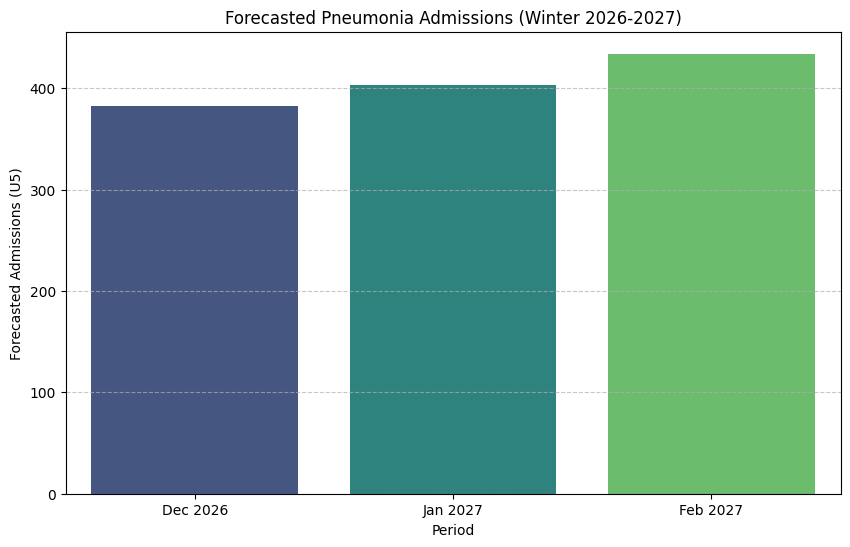

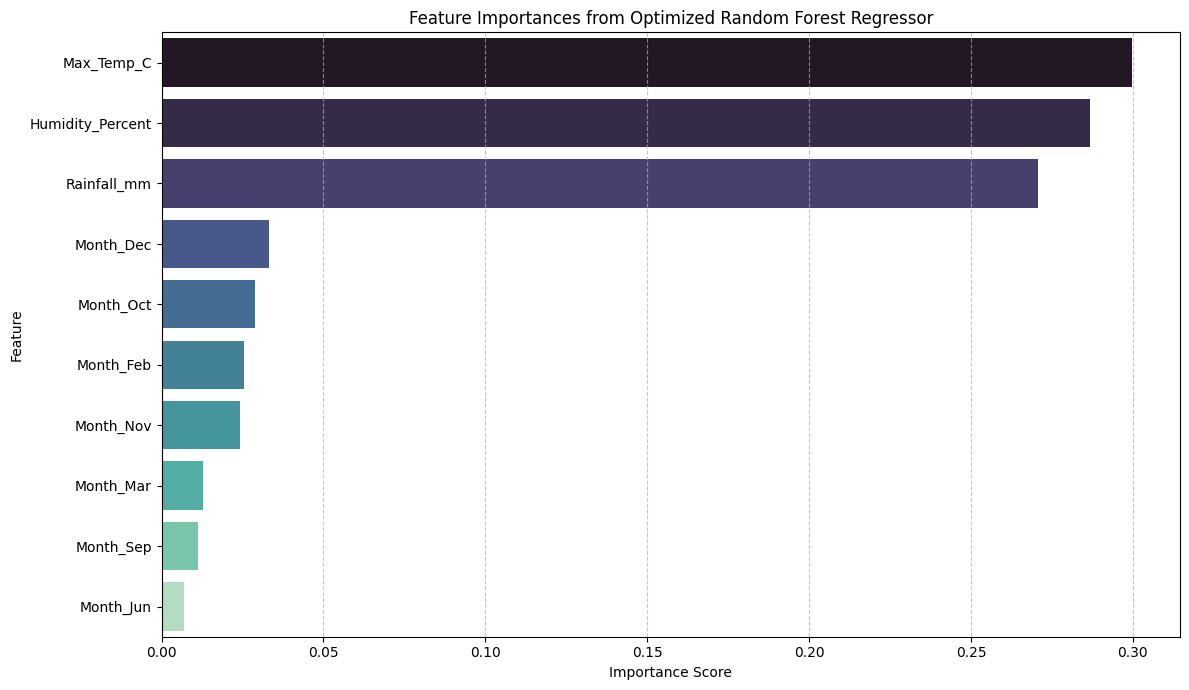

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Forecasted Pneumonia Admissions
plt.figure(figsize=(10, 6))
sns.barplot(x='Period', y='Forecasted_Pneumonia_Admissions_U5', data=forecast_results, palette='viridis')
plt.title('Forecasted Pneumonia Admissions (Winter 2026-2027)')
plt.xlabel('Period')
plt.ylabel('Forecasted Admissions (U5)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize Feature Importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_feature_importances.values, y=sorted_feature_importances.index, palette='mako')
plt.title('Feature Importances from Optimized Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
# 1. Create a target_scaler for inverse transformation
target_scaler = StandardScaler()
target_scaler.fit(df[[target_variable]])

# 2. Create a feature_scaler for the numerical selected features
numerical_selected_features = ['Max_Temp_C', 'Humidity_Percent', 'Rainfall_mm']
feature_scaler = StandardScaler()
feature_scaler.fit(df[numerical_selected_features])

# 3. Prepare future data for Dec 2026, Jan 2027, Feb 2027

forecast_periods = [
    {'month_name': 'Dec', 'year': 2026},
    {'month_name': 'Jan', 'year': 2027},
    {'month_name': 'Feb', 'year': 2027}
]

future_X_raw = []
future_index = []

for period in forecast_periods:
    month_name = period['month_name']
    year = period['year']
    future_index.append(f"{month_name} {year}")

    # Initialize a row for future features, all False/0 initially
    # Use selected_features to ensure column order and presence
    future_row_data = {col: False for col in selected_features}

    # Populate environmental features with monthly averages from historical data
    avg_values = monthly_avg[monthly_avg['Month'] == month_name]
    if not avg_values.empty:
        for feature in numerical_selected_features:
            future_row_data[feature] = avg_values[feature].values[0]
    else:
        # Fallback if a month is not found (shouldn't happen with full data)
        for feature in numerical_selected_features:
            future_row_data[feature] = df[feature].mean() # Use overall mean as a fallback

    # Set the appropriate one-hot encoded month feature to True (1)
    month_col_name = f'Month_{month_name}'
    if month_col_name in selected_features:
        future_row_data[month_col_name] = True
    # If the month is Jan and not in selected_features (baseline), all Month_XXX columns remain False.

    future_X_raw.append(pd.Series(future_row_data))

future_X_raw_df = pd.DataFrame(future_X_raw, index=future_index)

# Ensure correct data types for boolean columns before scaling numerical ones
for col in future_X_raw_df.columns:
    if col.startswith('Month_'):
        future_X_raw_df[col] = future_X_raw_df[col].astype(bool)
    elif col in numerical_selected_features:
        future_X_raw_df[col] = future_X_raw_df[col].astype(float)

# Scale numerical features in future_X_raw_df using feature_scaler
future_X_scaled = future_X_raw_df.copy()
future_X_scaled[numerical_selected_features] = feature_scaler.transform(future_X_scaled[numerical_selected_features])

# 4. Make predictions
scaled_predictions = best_rf_model.predict(future_X_scaled)

# 5. Inverse transform predictions to original scale
forecasted_admissions = target_scaler.inverse_transform(scaled_predictions.reshape(-1, 1)).flatten()

# Display results
forecast_results = pd.DataFrame({
    'Period': future_index,
    'Forecasted_Pneumonia_Admissions_U5': forecasted_admissions.round(0).astype(int) # Round to nearest integer for admissions
})
print("\n--- Forecasted Pneumonia Admissions for Winter 2026-2027 ---")
display(forecast_results)


--- Forecasted Pneumonia Admissions for Winter 2026-2027 ---


,Period,Forecasted_Pneumonia_Admissions_U5
0,Dec 2026,382
1,Jan 2027,403
2,Feb 2027,434


In [33]:
print("\n--- Feature Importances from Optimized Random Forest Regressor ---")
feature_importances = best_rf_model.feature_importances_

# Create a pandas Series for better visualization
feature_importance_series = pd.Series(feature_importances, index=selected_features)

# Sort the features by importance
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)
display(sorted_feature_importances)


--- Feature Importances from Optimized Random Forest Regressor ---


,0
Max_Temp_C,0.299588
Humidity_Percent,0.286820
Rainfall_mm,0.270838
Month_Dec,0.033254
Month_Oct,0.028845
Month_Feb,0.025365
Month_Nov,0.024344
Month_Mar,0.012681
Month_Sep,0.011322
Month_Jun,0.006943
